In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [7]:
matches=pd.read_csv("matches.csv")
deliveries=pd.read_csv("deliveries.csv")
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [8]:
matches.shape

(1095, 20)

In [9]:
deliveries.shape

(260920, 17)

In [12]:
matches.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [13]:
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [14]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [15]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [16]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [17]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [18]:
matches_clean = matches.dropna(subset=["winner"]).copy()

In [19]:
matches_clean.shape

(1090, 20)

In [20]:
matches_clean["date"] = pd.to_datetime(matches_clean["date"])

In [21]:
matches_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1090 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1090 non-null   int64         
 1   season           1090 non-null   object        
 2   city             1039 non-null   object        
 3   date             1090 non-null   datetime64[ns]
 4   match_type       1090 non-null   object        
 5   player_of_match  1090 non-null   object        
 6   venue            1090 non-null   object        
 7   team1            1090 non-null   object        
 8   team2            1090 non-null   object        
 9   toss_winner      1090 non-null   object        
 10  toss_decision    1090 non-null   object        
 11  winner           1090 non-null   object        
 12  result           1090 non-null   object        
 13  result_margin    1076 non-null   float64       
 14  target_runs      1090 non-null   float64     

In [24]:
matches_clean["year"] = matches_clean["date"].dt.year
matches_clean["bat_first"] = matches_clean["team1"]
matches_clean["bat_second"] = matches_clean["team2"]
matches_clean["win_type"] = matches_clean["result"]

In [26]:
matches_clean[["season", "date", "year", "team1", "team2", "winner", "win_type"]].tail()

,season,date,year,team1,team2,winner,win_type
1090,2024,2024-05-19,2024,Punjab Kings,Sunrisers Hyderabad,Sunrisers Hyderabad,wickets
1091,2024,2024-05-21,2024,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,wickets
1092,2024,2024-05-22,2024,Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,wickets
1093,2024,2024-05-24,2024,Sunrisers Hyderabad,Rajasthan Royals,Sunrisers Hyderabad,runs
1094,2024,2024-05-26,2024,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,wickets


In [43]:
team_wins = matches_clean["winner"].value_counts()
team_wins.head(10)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64

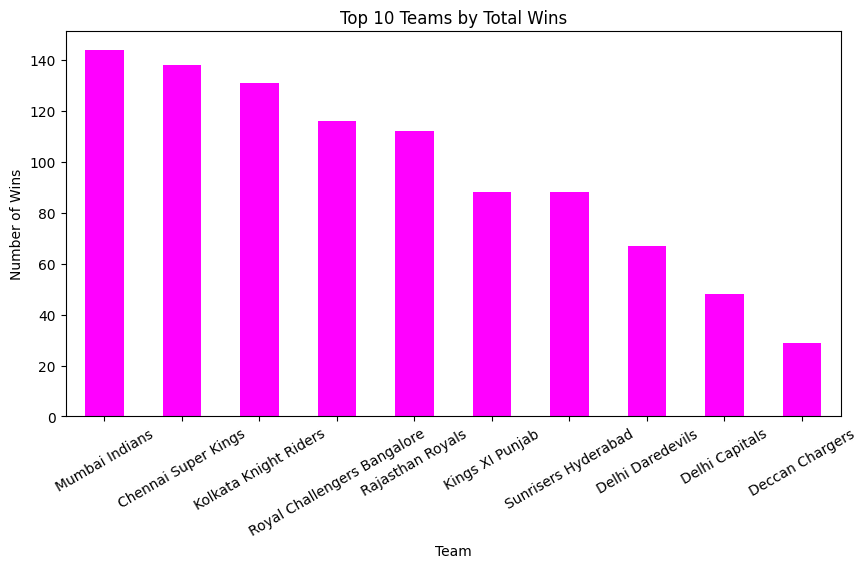

In [35]:
team_wins.head(10).plot(kind="bar", figsize=(10,5), color="magenta")
plt.title("Top 10 Teams by Total Wins")
plt.xlabel("Team")
plt.ylabel("Number of Wins")
plt.xticks(rotation=30)
plt.show()

In [41]:
team1_matches = matches_clean["team1"].value_counts()
team2_matches = matches_clean["team2"].value_counts()
total_matches = team1_matches.add(team2_matches, fill_value=0)
total_wins = matches_clean["winner"].value_counts()
win_percentage = (total_wins / total_matches) * 100
win_percentage = win_percentage.sort_values(ascending=False)
win_percentage

Rising Pune Supergiant         62.500000
Gujarat Titans                 62.222222
Chennai Super Kings            58.227848
Lucknow Super Giants           55.813953
Mumbai Indians                 55.172414
Delhi Capitals                 52.747253
Kolkata Knight Riders          52.191235
Rajasthan Royals               51.141553
Royal Challengers Bangalore    48.945148
Sunrisers Hyderabad            48.351648
Royal Challengers Bengaluru    46.666667
Kings XI Punjab                46.315789
Gujarat Lions                  43.333333
Kochi Tuskers Kerala           42.857143
Punjab Kings                   42.857143
Delhi Daredevils               42.138365
Deccan Chargers                38.666667
Rising Pune Supergiants        35.714286
Pune Warriors                  26.666667
Name: count, dtype: float64

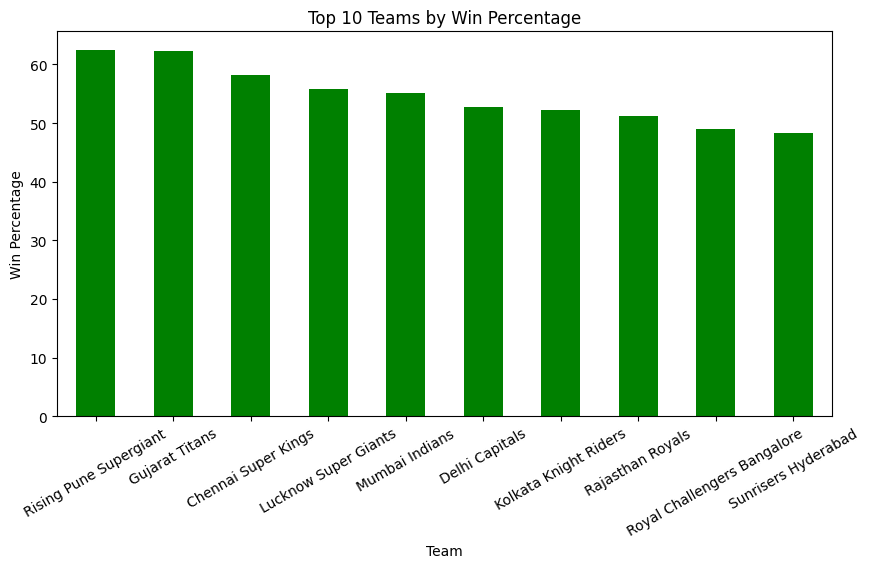

In [42]:
win_percentage.head(10).plot(kind="bar", figsize=(10, 5), color="green")
plt.title("Top 10 Teams by Win Percentage")
plt.xlabel("Team")
plt.ylabel("Win Percentage")
plt.xticks(rotation=30)
plt.show()

In [52]:
season_team_wins = matches_clean.groupby(["season", "winner"]).size().reset_index(name="wins")
season_team_wins

,season,winner,wins
0,2007/08,Chennai Super Kings,9
1,2007/08,Deccan Chargers,2
2,2007/08,Delhi Daredevils,7
3,2007/08,Kings XI Punjab,10
4,2007/08,Kolkata Knight Riders,6
...,...,...,...
141,2024,Mumbai Indians,4
142,2024,Punjab Kings,5
143,2024,Rajasthan Royals,9
144,2024,Royal Challengers Bengaluru,7


In [55]:
season_team_wins.sort_values(["season", "wins"], ascending=[True, False]).head(20)

,season,winner,wins
6,2007/08,Rajasthan Royals,13
3,2007/08,Kings XI Punjab,10
0,2007/08,Chennai Super Kings,9
2,2007/08,Delhi Daredevils,7
5,2007/08,Mumbai Indians,7
4,2007/08,Kolkata Knight Riders,6
7,2007/08,Royal Challengers Bangalore,4
1,2007/08,Deccan Chargers,2
10,2009,Delhi Daredevils,10
9,2009,Deccan Chargers,9


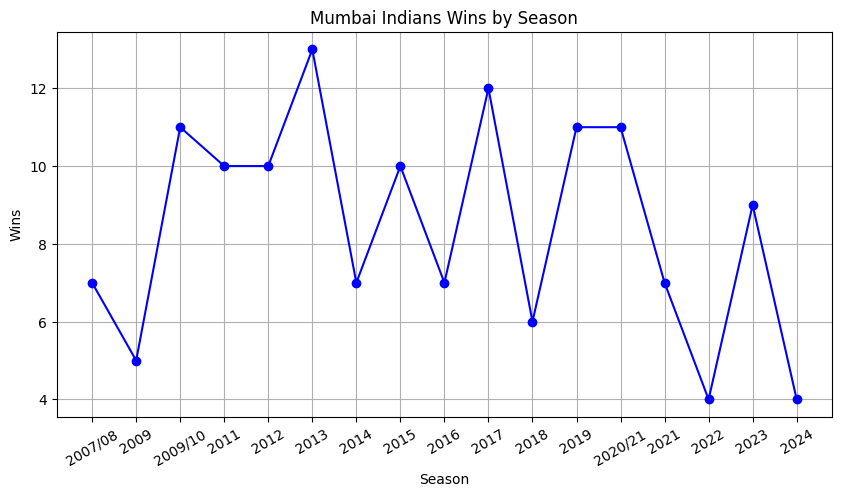

In [54]:
mi_wins = season_team_wins[season_team_wins["winner"] == "Mumbai Indians"]
plt.figure(figsize=(10, 5))
plt.plot(mi_wins["season"], mi_wins["wins"], marker="o", color="blue")
plt.title("Mumbai Indians Wins by Season")
plt.xlabel("Season")
plt.xticks(rotation=30)
plt.ylabel("Wins")
plt.grid("True")
plt.show()

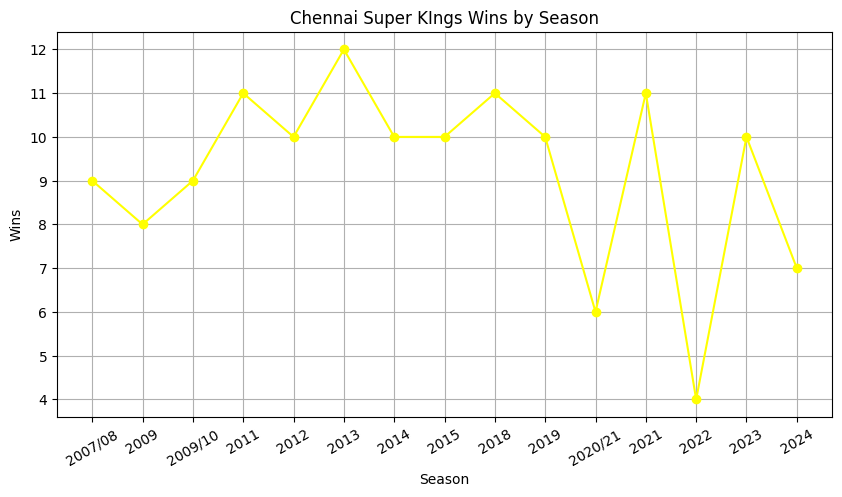

In [57]:
csk_wins = season_team_wins[season_team_wins["winner"] == "Chennai Super Kings"]
plt.figure(figsize=(10, 5))
plt.plot(csk_wins["season"], csk_wins["wins"], marker="o", color="yellow")
plt.title("Chennai Super KIngs Wins by Season")
plt.xlabel("Season")
plt.xticks(rotation=30)
plt.ylabel("Wins")
plt.grid("True")
plt.show()

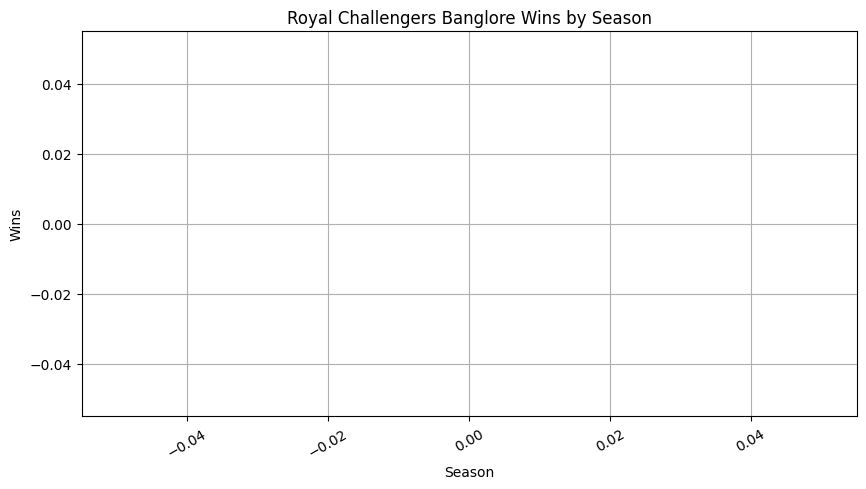

In [59]:
rcb_wins = season_team_wins[season_team_wins["winner"] == "Royal Challengers Banglore"]
plt.figure(figsize=(10, 5))
plt.plot(rcb_wins["season"], rcb_wins["wins"], marker="o", color="red")
plt.title("Royal Challengers Banglore Wins by Season")
plt.xlabel("Season")
plt.xticks(rotation=30)
plt.ylabel("Wins")
plt.grid("True")
plt.show()

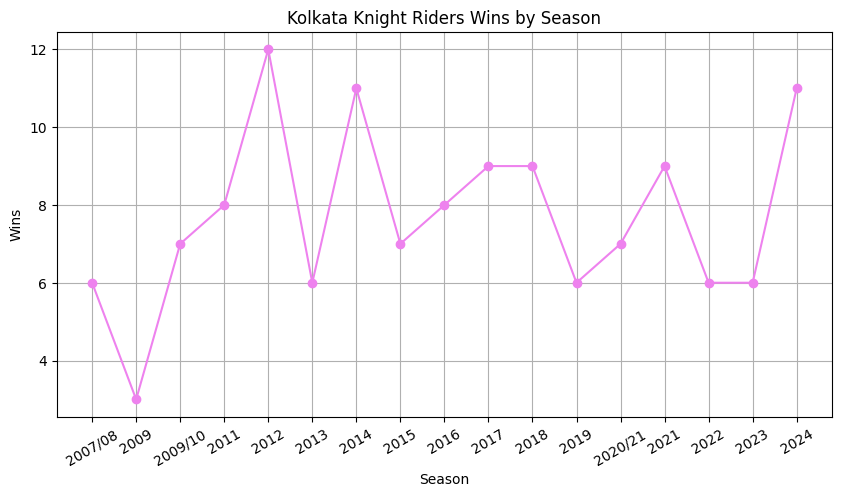

In [60]:
kkr_wins = season_team_wins[season_team_wins["winner"] == "Kolkata Knight Riders"]
plt.figure(figsize=(10, 5))
plt.plot(kkr_wins["season"], kkr_wins["wins"], marker="o", color="violet")
plt.title("Kolkata Knight Riders Wins by Season")
plt.xlabel("Season")
plt.xticks(rotation=30)
plt.ylabel("Wins")
plt.grid("True")
plt.show()

In [83]:
batter_runs = deliveries.groupby("batter")["batsman_runs"].sum()
batter_balls = deliveries.groupby("batter")["ball"].count()
batter_stats = pd.DataFrame({"runs": batter_runs,"balls": batter_balls})
batter_stats["strike_rate"] = (batter_stats["runs"] / batter_stats["balls"]) * 100
batter_stats_filtered = batter_stats[batter_stats["balls"] >= 500]
top_runs = batter_stats_filtered.sort_values("runs", ascending=False).head(10)
top_runs

,runs,balls,strike_rate
batter,,,
V Kohli,8014,6236,128.511867
S Dhawan,6769,5483,123.454313
RG Sharma,6630,5183,127.918194
DA Warner,6567,4849,135.429986
SK Raina,5536,4177,132.535312
MS Dhoni,5243,3947,132.835065
AB de Villiers,5181,3487,148.580442
CH Gayle,4997,3516,142.121729
RV Uthappa,4954,3927,126.152279


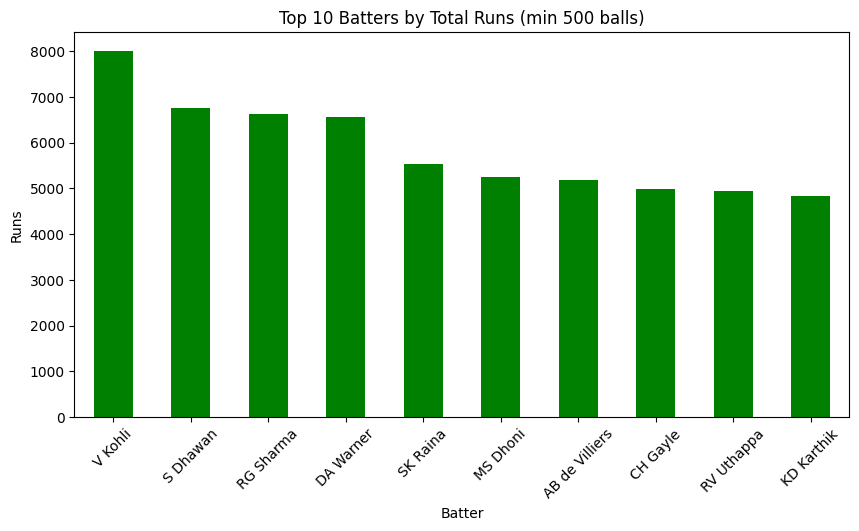

In [84]:
top_runs["runs"].plot(kind="bar", figsize=(10, 5), color="green")
plt.title("Top 10 Batters by Total Runs (min 500 balls)")
plt.xlabel("Batter")
plt.ylabel("Runs")
plt.xticks(rotation=45)
plt.show()

In [63]:
top_sr = batter_stats_filtered.sort_values("strike_rate", ascending=False).head(10)
top_sr

,runs,balls,strike_rate
batter,,,
AD Russell,2488,1515,164.224422
H Klaasen,993,613,161.990212
SP Narine,1534,984,155.894309
N Pooran,1769,1143,154.768154
LS Livingstone,939,609,154.187192
GJ Maxwell,2772,1842,150.488599
RM Patidar,799,534,149.625468
Abhishek Sharma,1377,925,148.864865
V Sehwag,2728,1833,148.827059


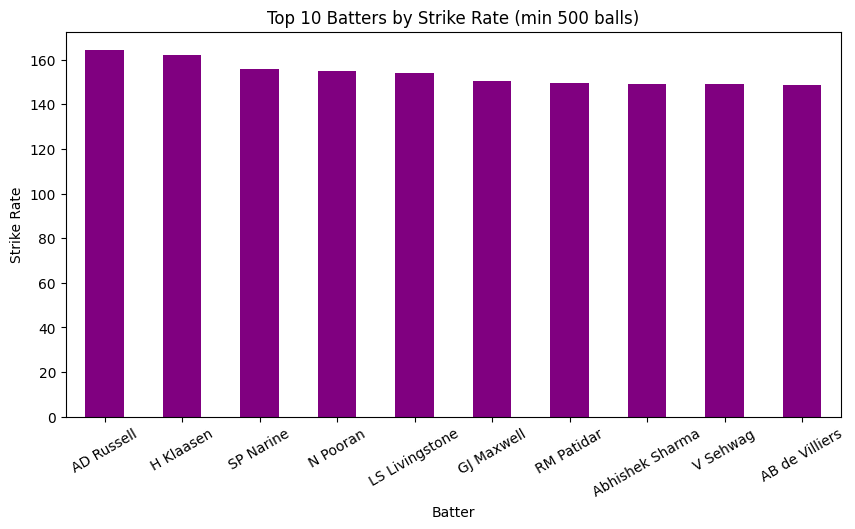

In [66]:
top_sr["strike_rate"].plot(kind="bar", figsize=(10, 5), color="purple")
plt.title("Top 10 Batters by Strike Rate (min 500 balls)")
plt.xlabel("Batter")
plt.ylabel("Strike Rate")
plt.xticks(rotation=30)
plt.show()

In [81]:
bowler_stats_filtered = bowler_stats[bowler_stats["balls"] >= 300]
top_wickets = bowler_stats_filtered.sort_values("wickets", ascending=False).head(10)
top_economy = bowler_stats_filtered.sort_values("economy").head(10)
print(top _economy)

                  runs_conceded  balls  wickets       overs   economy
bowler                                                               
A Kumble                   1089    983       49  163.833333  6.646999
GD McGrath                  366    329       14   54.833333  6.674772
M Muralitharan             1765   1581       67  263.500000  6.698292
J Yadav                     447    398        9   66.333333  6.738693
SP Narine                  4672   4146      200  691.000000  6.761216
RE van der Merwe            515    455       25   75.833333  6.791209
DW Steyn                   2583   2282      105  380.333333  6.791411
DL Vettori                  894    785       34  130.833333  6.833121
Rashid Khan                3340   2901      157  483.500000  6.907963
J Botha                     818    709       27  118.166667  6.922426


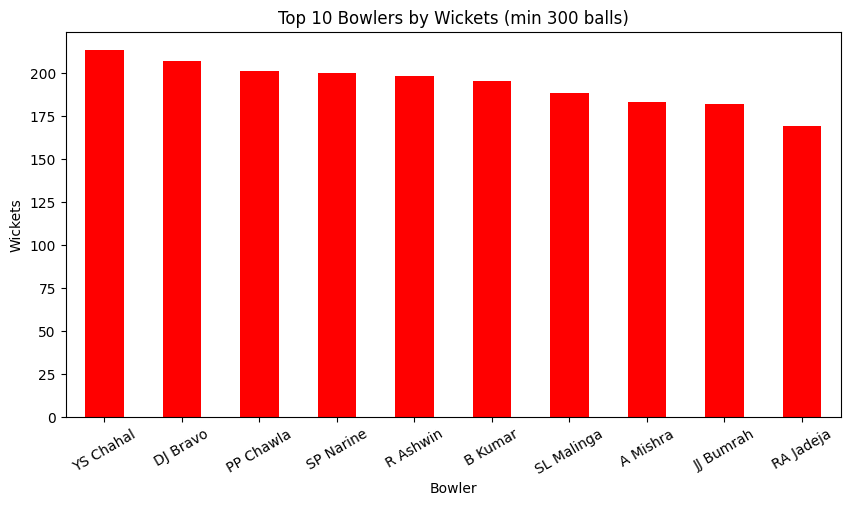

In [79]:
top_wickets["wickets"].plot(kind="bar", figsize=(10, 5), color="red")
plt.title("Top 10 Bowlers by Wickets (min 300 balls)")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.xticks(rotation=30)
plt.show()

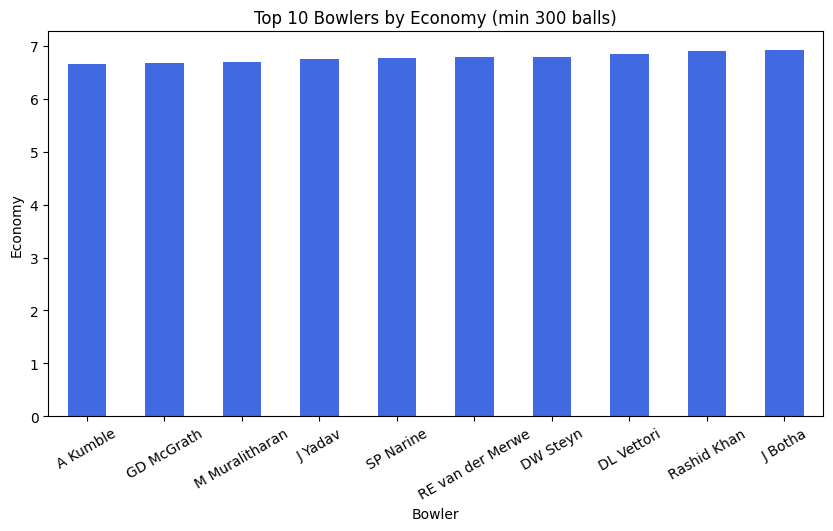

In [75]:
top_economy["economy"].plot(kind="bar", figsize=(10, 5), color="royalblue")
plt.title("Top 10 Bowlers by Economy (min 300 balls)")
plt.xlabel("Bowler")
plt.ylabel("Economy")
plt.xticks(rotation=30)
plt.show()